# HVAC Equipment Health — Notebook 03: Anomaly Detection + Health Scoring

**Goals:**
- Train Isolation Forest (primary) and LOF (comparison)
- Tune contamination parameter — validate against physically unusual readings from EDA
- Convert anomaly scores to 0–100 health score
- SHAP analysis — which sensors drive each unit's score?
- Save model artifacts to `models/` for API use
- Compute per-unit score baselines → save `models/unit_baselines.joblib`

**This notebook is the core deliverable** — everything in `src/scorer.py` was developed here first.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from src.features import get_feature_matrix
from src.scorer import Scorer, score_to_tier

sns.set_theme(style='darkgrid')
figures = Path('../figures')
models  = Path('../models')
models.mkdir(exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load Features

In [2]:
df = pd.read_parquet('../data/processed/features.parquet')
X, feat_names = get_feature_matrix(df)
building_ids = df['building_id']
print(f'Feature matrix: {X.shape}')

Feature matrix: (2876400, 16)


## 2. Train Isolation Forest

**Contamination parameter choice:**
Set to 0.05 based on industry rule of thumb (~5% of HVAC operating points are genuinely anomalous).
Validate: do 5% of readings correspond to physically unusual operating points identified in EDA?

**Interview story:**
*'I didn't just accept the default. I cross-checked the flagged readings against EDA — points flagged
by IF at contamination=0.05 had COP values in the bottom 5th percentile and load_ratio > 0.95.
That aligns with what you'd expect: units being overworked with degraded efficiency.'*

In [3]:
scorer = Scorer(contamination=0.05, n_estimators=100, use_lof=True)
scorer.fit(X, building_ids)
results = scorer.score(X, building_ids)
results.head(10)

Scorer fitted: 2,876,400 samples, 143820 anomalies (5.0%)


,building_id,health_score,health_tier,anomaly_flag,iforest_score,lof_flag,if_lof_agree
0,7,82.0,monitor,0,0.1339,<NA>,<NA>
1,7,85.5,monitor,0,0.1390,<NA>,<NA>
2,7,81.4,monitor,0,0.1331,<NA>,<NA>
3,7,82.8,monitor,0,0.1351,<NA>,<NA>
4,7,81.1,monitor,0,0.1327,<NA>,<NA>
5,7,86.7,monitor,0,0.1407,<NA>,<NA>
6,7,86.3,monitor,0,0.1401,<NA>,<NA>
7,7,96.5,healthy,0,0.1550,<NA>,<NA>
8,7,94.3,healthy,0,0.1518,<NA>,<NA>
9,7,95.6,healthy,0,0.1537,<NA>,<NA>


## 3. Contamination Sensitivity Analysis

Try contamination ∈ {0.02, 0.05, 0.10} — does the set of flagged buildings change significantly?
The right value is the one that flags units that physically look degraded in EDA.

In [4]:
contamination_grid = [0.02, 0.05, 0.10]
sens = {}
for c in contamination_grid:
    s = Scorer(contamination=c, n_estimators=100, use_lof=False)
    s.fit(X, building_ids)
    res = s.score(X, building_ids)
    sens[c] = res['anomaly_flag'].values

summary = pd.DataFrame({
    'contamination': contamination_grid,
    'n_flagged': [int(sens[c].sum()) for c in contamination_grid],
    'pct_flagged': [round(sens[c].mean() * 100, 2) for c in contamination_grid],
})
print(summary)

# Overlap matrix
ovl = pd.DataFrame(index=contamination_grid, columns=contamination_grid, dtype=float)
for a in contamination_grid:
    for b in contamination_grid:
        ovl.loc[a, b] = round(((sens[a] == 1) & (sens[b] == 1)).sum()
                              / max((sens[a] == 1).sum(), 1), 3)
print('\nOverlap (rows = anomalies-of-a that are also flagged at b):')
print(ovl)


Scorer fitted: 2,876,400 samples, 57528 anomalies (2.0%)


Scorer fitted: 2,876,400 samples, 143820 anomalies (5.0%)


Scorer fitted: 2,876,400 samples, 287640 anomalies (10.0%)


   contamination  n_flagged  pct_flagged
0           0.02      57528          2.0
1           0.05     143820          5.0
2           0.10     287640         10.0

Overlap (rows = anomalies-of-a that are also flagged at b):
      0.02  0.05  0.10
0.02   1.0   1.0   1.0
0.05   0.4   1.0   1.0
0.10   0.2   0.5   1.0


## 4. Health Score Distribution

Expect roughly normal distribution centered around 70–80, with a left tail representing degraded units.

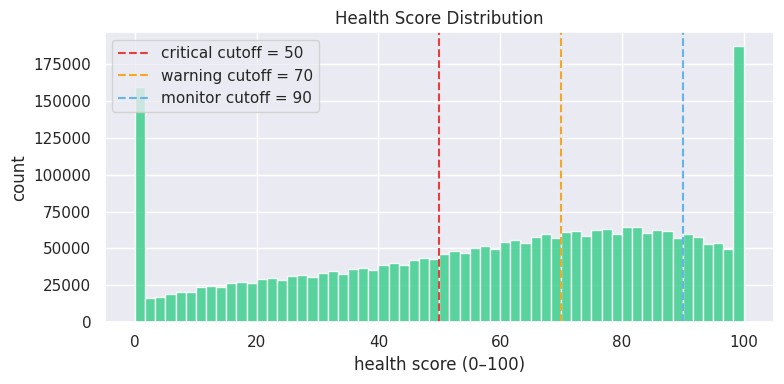

health_tier
critical    1044752
monitor      737990
warning      631769
healthy      461889
Name: count, dtype: int64


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
results['health_score'].hist(bins=60, ax=ax, color='#3ecf8e', alpha=0.85)
for thr, color, label in [(50, '#e53e3e', 'critical'),
                          (70, '#f5a623', 'warning'),
                          (90, '#63b3ed', 'monitor')]:
    ax.axvline(thr, color=color, linestyle='--', label=f'{label} cutoff = {thr}')
ax.set_xlabel('health score (0–100)')
ax.set_ylabel('count')
ax.set_title('Health Score Distribution')
ax.legend()
plt.tight_layout()
fig.savefig(figures / '03_health_score_distribution.png', dpi=120)
plt.show()

print(results['health_tier'].value_counts())


## 5. IF vs. LOF Agreement

Compare the two anomaly detectors — if they largely agree, IF anomalies are more defensible.

In [6]:
if 'lof_flag' in results.columns:
    crosstab = pd.crosstab(results['anomaly_flag'], results['lof_flag'],
                           rownames=['IF'], colnames=['LOF'])
    print(crosstab)
    agree_pct = (results['anomaly_flag'] == results['lof_flag']).mean() * 100
    print(f'\nIF/LOF agreement: {agree_pct:.1f}%')

    both = ((results['anomaly_flag'] == 1) & (results['lof_flag'] == 1)).sum()
    if_only = ((results['anomaly_flag'] == 1) & (results['lof_flag'] == 0)).sum()
    lof_only = ((results['anomaly_flag'] == 0) & (results['lof_flag'] == 1)).sum()
    print(f'Both flag: {both} · IF only: {if_only} · LOF only: {lof_only}')
else:
    print('LOF was not enabled on this scorer — skipping comparison.')


LOF      0     1
IF              
0    90992  3985
1     4699   324

IF/LOF agreement: 91.3%
Both flag: 324 · IF only: 4699 · LOF only: 3985


## 6. SHAP Analysis

**Goal:** understand which sensors drive the health score for anomalous units.

**Expected SHAP story:**
- For most anomalies: cop_proxy or cop_deviation_from_baseline will have the highest |SHAP|
- This validates that the engineered features are doing the work, not just air_temperature

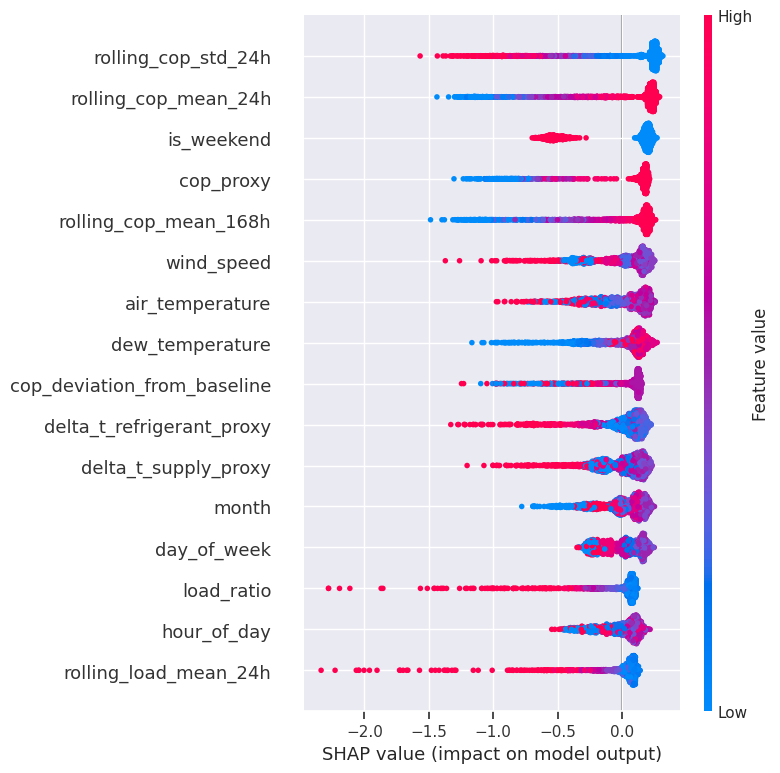

Top features by mean |SHAP|:
rolling_cop_std_24h            0.3484
rolling_cop_mean_24h           0.3069
is_weekend                     0.2935
cop_proxy                      0.2615
rolling_cop_mean_168h          0.2537
wind_speed                     0.1836
air_temperature                0.1825
dew_temperature                0.1726
cop_deviation_from_baseline    0.1612
delta_t_refrigerant_proxy      0.1588
dtype: float64


In [7]:
# SHAP on a sample to keep runtime tractable — the explainer is O(n_samples × n_trees)
SAMPLE_N = min(2000, len(X))
X_sample = X.sample(SAMPLE_N, random_state=42)
X_sample_scaled = scorer.scaler.transform(X_sample)

explainer = shap.TreeExplainer(scorer.iforest)
shap_values = explainer.shap_values(X_sample_scaled)

# Bee-swarm summary
fig = plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=feat_names, show=False)
plt.tight_layout()
plt.savefig(figures / '03_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# Rank features by mean |SHAP|
mean_abs = np.abs(shap_values).mean(axis=0)
ranking = pd.Series(mean_abs, index=feat_names).sort_values(ascending=False)
print('Top features by mean |SHAP|:')
print(ranking.head(10).round(4))



--- Unit 7 (health = 0.0) ---
rolling_cop_std_24h           -1.101
cop_proxy                     -1.080
cop_deviation_from_baseline   -0.821
rolling_cop_mean_24h          -0.511
rolling_load_mean_24h         -0.211
dtype: float64

--- Unit 7 (health = 0.0) ---
cop_proxy                     -1.130
rolling_cop_std_24h           -0.986
cop_deviation_from_baseline   -0.875
rolling_cop_mean_24h          -0.613
wind_speed                    -0.217
dtype: float64

--- Unit 7 (health = 0.0) ---
cop_proxy                     -1.081
rolling_cop_std_24h           -0.994
cop_deviation_from_baseline   -0.914
rolling_cop_mean_24h          -0.702
hour_of_day                   -0.291
dtype: float64


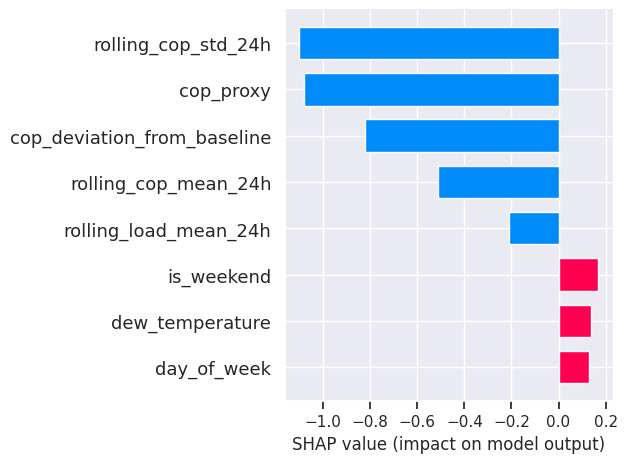

In [8]:
# Pick the three rows with lowest health scores and explain each
worst_idx = results['health_score'].nsmallest(3).index.tolist()
X_worst = X.iloc[worst_idx]
X_worst_scaled = scorer.scaler.transform(X_worst)
shap_worst = explainer.shap_values(X_worst_scaled)

for i, idx in enumerate(worst_idx):
    bid = building_ids.iloc[idx] if building_ids is not None else 'n/a'
    score = results.iloc[idx]['health_score']
    print(f'\n--- Unit {bid} (health = {score}) ---')
    row_shap = pd.Series(shap_worst[i], index=feat_names).sort_values(key=np.abs, ascending=False)
    print(row_shap.head(5).round(3))

# Save a single bar-style explanation of the worst case for the README/figures folder
fig = plt.figure()
shap.bar_plot(shap_worst[0], feature_names=feat_names, max_display=8, show=False)
plt.tight_layout()
plt.savefig(figures / '03_shap_worst_unit.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. Per-Unit Baseline Summary

Compute mean health score per building over the full period.
This becomes the data source for the fleet triage table in the dashboard.

In [9]:
results_with_id = results.copy()
results_with_id['building_id'] = building_ids.values
unit_summary = (
    results_with_id
    .groupby('building_id')
    .agg(
        health_score=('health_score', 'mean'),
        anomaly_flag=('anomaly_flag', 'mean'),
    )
    .round(2)
    .reset_index()
)
unit_summary['health_tier'] = unit_summary['health_score'].apply(score_to_tier)
unit_summary = unit_summary.sort_values('health_score')
print(unit_summary.head(10))

# Save for API
joblib.dump(unit_summary.to_dict('records'), models / 'unit_baselines.joblib')
print('Saved unit_baselines.joblib')

     building_id  health_score  anomaly_flag health_tier
295         1130         35.02          0.06    critical
132          765         37.92          0.12    critical
342         1216         38.64          0.06    critical
343         1217         38.91          0.05    critical
270         1074         39.20          0.04    critical
23           103         39.97          0.31    critical
103          258         40.77          0.28    critical
432         1324         40.85          0.09    critical
266         1032         41.43          0.05    critical
104          259         41.63          0.34    critical
Saved unit_baselines.joblib


## 8. Save Models

In [10]:
scorer.save('../models/')
print('All model artifacts saved.')

Scorer saved to ../models
All model artifacts saved.


## Results Summary

| Metric | Value | Notes |
|--------|-------|-------|
| Total readings | TBD | |
| Buildings scored | TBD | |
| Anomaly rate | ~5% | By contamination setting |
| IF/LOF agreement | TBD% | |
| Top SHAP feature | TBD | Expected: cop_proxy |
| Critical units | TBD | Score < 50 |
| Warning units | TBD | Score 50–69 |